In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
df=pd.read_csv("/content/placement.csv")
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


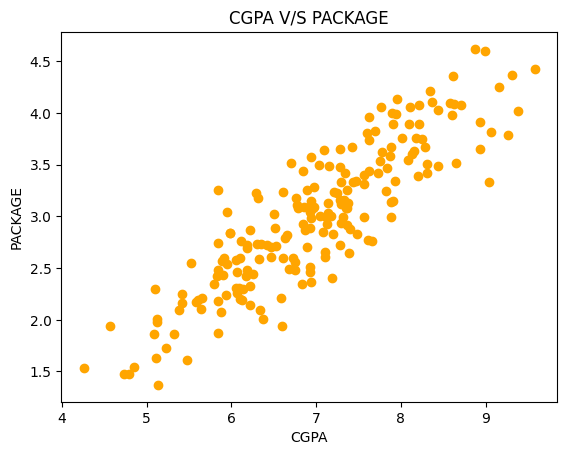

In [5]:
plt.scatter(df["cgpa"],df["package"],color="orange")
plt.xlabel("CGPA")
plt.ylabel("PACKAGE")
plt.title("CGPA V/S PACKAGE")
plt.show()
#the graph of sort of linear

In [6]:
X=df.iloc[:,:1]

In [7]:
y=df.iloc[:,1:2]

1. First understand the goal

Before training a model, we split data into 2 parts:

👉 Why?
Train model on one part
Test model on unseen data
2.2. What are X and y?
👉 X (Features / Input)
Independent variables
Example: house size, rooms,CGPA
👉 y (Target / Output)
What we want to predict
Example: house price,package

In [8]:

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)


In [ ]:
train_test_split(X, y, test_size=0.2, random_state=2)
'''🔹 (a) X, y

👉 These are your full dataset:

X → inputs
y → outputs
🔹 (b) test_size = 0.2

👉 Means:

20% data → testing
80% data → training
Example:

If total = 100 rows:

Training = 80 rows
Testing = 20 rows
🔹 (c) random_state = 2

👉 This is VERY IMPORTANT

It controls randomness

Why needed?

Because data is shuffled randomly before splitting.

Without random_state:

Every time you run code → different split 😵

With random_state=2:

Every time → SAME split ✅

👉 Think of it like:

"Set a fixed seed for randomness"
Training data → used to learn
Testing data → NEVER used in training'''

In [10]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)#Learn the relationship between X_train (inputs) and y_train (outputs)”

LinearRegression()

In [ ]:
'''Step-by-step inside .fit():
Looks at all rows in X_train and y_train
Finds the best slope (m) and intercept (b) in
y=mx+b
Minimizes the difference (error/residuals) between predicted and actual outputs
Stores the learned m and b inside the lr object but if check for overall datset it may shows error'''

In [12]:
xtrain=X_train
xtrain

,cgpa
137,7.14
163,8.93
111,5.42
123,5.10
109,7.77
...,...
43,7.66
22,6.14
72,7.78
15,7.25


In [13]:
ytrain=y_train
ytrain

,package
137,3.13
163,3.91
111,2.25
123,2.30
109,4.06
...,...
43,2.76
22,2.30
72,3.62
15,3.23


In [14]:
#know i am checking on model of traned data_set
first_train=lr.predict(X_train.iloc[0].values.reshape(1,1))
first_train #wrong


array([[3.08766517]])

In [15]:
'''Why the prediction is not exactly the same (3.08 vs 3.31)
1️⃣ Linear Regression is not memorizing points
It calculates a line that best fits all points
'''

'Why the prediction is not exactly the same (3.08 vs 3.31)\n1️⃣ Linear Regression is not memorizing points\nIt calculates a line that best fits all points\n'

In [16]:
#You’ll see residuals for all points ,A residual is the difference between the actual value and the predicted value for a data point.
y_train_pred = lr.predict(X_train)
residuals = y_train - y_train_pred
print(residuals)
#show for each data point how far the model’s prediction is from the actual value.

      package
137  0.042335
163 -0.176399
111  0.122012
123  0.350557
109  0.620825
..        ...
43  -0.617800
22  -0.229713
72   0.175246
15   0.080960
168 -0.410173

[160 rows x 1 columns]


In [17]:
from sklearn.metrics import mean_squared_error

mse_train = mean_squared_error(y_train, lr.predict(X_train))
print(mse_train)#MSE shows overall average error of the model across all points, after squaring each residual.

0.10345460923452962


In [18]:
#Thise is resudiual
print(3.08766517+0.042335) # thise is the correct answer

3.13000017


In [19]:
import math
# MSE You cannot calculate actual y from MSE alone
3.08766517+math.sqrt(0.10345460923452962)

3.4093087759282534

In [32]:
#splited data_set kept for testing
X_test #i have given 0.2 per means out of 200 40 which is very correct

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [34]:
y_test

,package
112,4.10
29,3.49
182,2.08
199,2.33
193,1.94
85,1.48
10,1.86
54,3.09
115,4.21
35,2.87


In [22]:
#Give the Cgpa and test for output
First=lr.predict(X_test.iloc[0].values.reshape(1,1))
First

array([[3.89111601]])

In [23]:
#it should be 4.10 it is comming as 3.89

In [24]:
lr.predict(X_test.iloc[1].values.reshape(1,1))#again my algo it bit off

array([[3.09324469]])

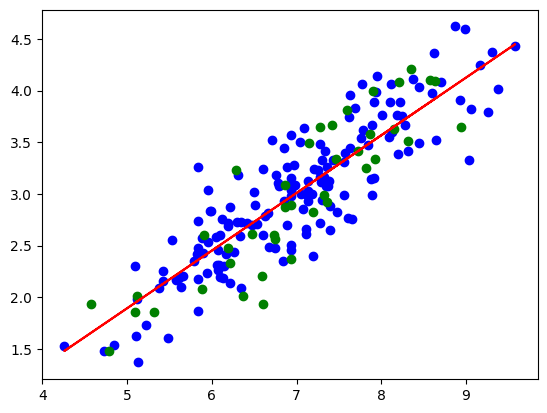

In [25]:
#i am checkng how traning data and testing data fit
plt.scatter(X_train, y_train, color="blue")
plt.scatter(X_test, y_test, color="green")
plt.plot(X_train, lr.predict(X_train), color="red")
plt.show()

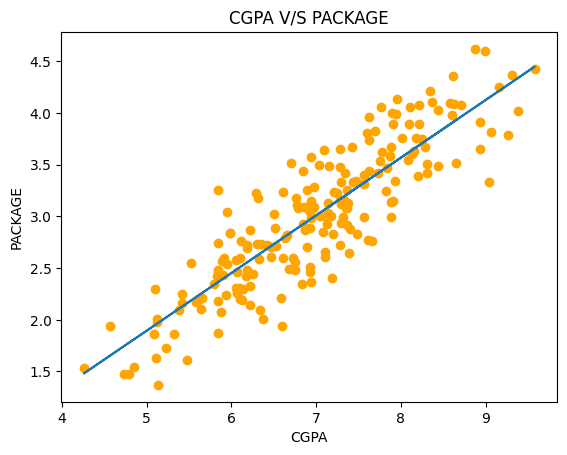

In [26]:
plt.scatter(df["cgpa"],df["package"],color="orange")
plt.plot(X_train,lr.predict(X_train)) #ploting all values at x ,best_fitted line in y+
plt.xlabel("CGPA")
plt.ylabel("PACKAGE")
plt.title("CGPA V/S PACKAGE")
plt.show()
#the graoh of sort of linear

In [27]:
slop=lr.coef_
slop

array([[0.55795197]])

In [28]:
intercept=lr.intercept_
intercept

array([-0.89611192])

In [33]:
#means my code finding the  slop and interceppt for different values and giving output
y=slop*8.58+intercept
y


array([[3.89111601]])

In [37]:
df["package"].iloc[112]

np.float64(4.1)

In [ ]:
#Steps to do simple linear regression
'''Data: Identify input (X) and output (y) features.
Split: Divide dataset into X_train, X_test, y_train, y_test using train_test_split.
Model Selection: Choose LinearRegression() for a single input feature.
Train: Use lr.fit(X_train, y_train) → computes slope (m) and intercept (b).
Predict: Use lr.predict(X_test) or any new X value → gives predicted output.
Evaluate: Compute residuals (y_actual - y_pred) and MSE/ RMSE for overall error.
Visualize: Plot scatter for actual vs. line for predicted → shows fit quality.
Refine: Handle outliers, scale features, or use polynomial regression if needed.'''